
gRNA Barcode Deconvolution Framework
=====================================
Simulates 4-color ISS chemistry for combinatorial CRISPR screens.
Tests whether pairs of gRNAs can be distinguished from summed signals.

Usage:
1. Load your gRNA spacer sequences
2. Run collision detection for 10nt vs 20nt prefixes
3. Attempt deconvolution from simulated sum-signals



In [1]:
import numpy as np
from itertools import combinations_with_replacement
from collections import defaultdict
from typing import List, Tuple, Dict, Optional

# PART 1: Data Loading

In [30]:
def load_spacers_from_csv(filepath: str, spacer_col: str = 'spacer', n: int = 52) -> List[str]:
    """
    Load first n gRNA spacer sequences from CSV.
    
    Parameters
    ----------
    filepath : str
        Path to CSV with gRNA library
    spacer_col : str
        Column name containing spacer sequences
    n : int
        Number of gRNAs to use
    
    Returns
    -------
    List[str]
        List of spacer sequences (uppercase)
    """
    import pandas as pd
    df = pd.read_csv(filepath)
    spacers = df[spacer_col].str[20:].head(n).str.upper().tolist()
    return spacers

# PART 2: 4-Color Chemistry Encoding

In [3]:
# 4-color encoding: each base -> one-hot vector
BASE_TO_4COLOR = {
    'A': np.array([1, 0, 0, 0]),
    'C': np.array([0, 1, 0, 0]),
    'G': np.array([0, 0, 1, 0]),
    'T': np.array([0, 0, 0, 1]),
}

def encode_barcode_4color(sequence: str) -> np.ndarray:
    """
    Encode a barcode sequence as 4-color intensity matrix.
    
    Parameters
    ----------
    sequence : str
        DNA sequence (barcode/spacer)
    
    Returns
    -------
    np.ndarray
        Shape (L, 4) where L = sequence length
        Each row is one-hot encoding of base at that position
    """
    return np.array([BASE_TO_4COLOR[base] for base in sequence.upper()])


In [4]:
def compute_pair_sum(seq1: str, seq2: str, prefix_len: Optional[int] = None) -> np.ndarray:
    """
    Compute summed 4-color signal for a pair of barcodes.
    Assumes 50:50 abundance (equal contribution from each).
    
    Parameters
    ----------
    seq1, seq2 : str
        Two barcode sequences
    prefix_len : int, optional
        Use only first N nucleotides. If None, use full length.
    
    Returns
    -------
    np.ndarray
        Shape (L, 4) summed intensity matrix
    """
    if prefix_len:
        seq1 = seq1[:prefix_len]
        seq2 = seq2[:prefix_len]
    
    enc1 = encode_barcode_4color(seq1)
    enc2 = encode_barcode_4color(seq2)
    
    return enc1 + enc2  # 50:50 sum


In [5]:
def signal_to_hashable(signal: np.ndarray) -> tuple:
    """Convert signal matrix to hashable tuple for dictionary lookup."""
    return tuple(map(tuple, signal))

# PART 3: Collision Detection

In [6]:
def detect_collisions(spacers: List[str], prefix_len: Optional[int] = None) -> Dict:
    """
    Find all pairs that produce identical summed signals (collisions).
    
    Parameters
    ----------
    spacers : List[str]
        List of gRNA spacer sequences
    prefix_len : int, optional
        Use only first N nucleotides
    
    Returns
    -------
    dict with keys:
        'n_pairs': total number of unique pairs
        'n_unique_sums': number of distinct sum-patterns
        'n_collisions': number of pairs that collide with another pair
        'collision_groups': dict mapping sum-pattern -> list of pairs
        'distinguishable': bool, True if all pairs are unique
    """
    n = len(spacers)
    
    # Generate all unordered pairs (including self-pairs)
    all_pairs = list(combinations_with_replacement(range(n), 2))
    
    # Map sum-pattern -> list of pairs that produce it
    sum_to_pairs = defaultdict(list)
    
    for i, j in all_pairs:
        pair_sum = compute_pair_sum(spacers[i], spacers[j], prefix_len)
        sum_hash = signal_to_hashable(pair_sum)
        sum_to_pairs[sum_hash].append((i, j))
    
    # Find collisions (sum-patterns with >1 pair)
    collision_groups = {k: v for k, v in sum_to_pairs.items() if len(v) > 1}
    n_colliding_pairs = sum(len(v) for v in collision_groups.values())
    
    return {
        'n_pairs': len(all_pairs),
        'n_unique_sums': len(sum_to_pairs),
        'n_collisions': len(collision_groups),
        'n_colliding_pairs': n_colliding_pairs,
        'collision_groups': collision_groups,
        'distinguishable': len(collision_groups) == 0,
        'prefix_len': prefix_len or len(spacers[0]),
    }

In [7]:
def compare_prefix_lengths(spacers: List[str], lengths: List[int] = [5, 10, 20]) -> None:
    """
    Compare collision rates across different barcode prefix lengths.
    
    Parameters
    ----------
    spacers : List[str]
        List of gRNA spacer sequences
    lengths : List[int]
        Prefix lengths to test
    """
    print("=" * 60)
    print("COLLISION ANALYSIS: Prefix Length Comparison")
    print("=" * 60)
    print(f"Library size: {len(spacers)} gRNAs")
    print(f"Total unique pairs: {len(spacers) * (len(spacers) + 1) // 2}")
    print()
    
    for L in lengths:
        result = detect_collisions(spacers, prefix_len=L)
        
        print(f"Prefix length: {L}nt")
        print(f"  Unique sum-patterns: {result['n_unique_sums']}")
        print(f"  Collision groups: {result['n_collisions']}")
        print(f"  Colliding pairs: {result['n_colliding_pairs']}")
        print(f"  Distinguishable: {result['distinguishable']}")
        print()

# PART 4: Build Lookup Table for Deconvolution

In [8]:
def build_lookup_table(spacers: List[str], prefix_len: Optional[int] = None) -> Dict:
    """
    Build lookup table mapping sum-patterns to pair identities.
    
    Parameters
    ----------
    spacers : List[str]
        List of gRNA spacer sequences
    prefix_len : int, optional
        Use only first N nucleotides
    
    Returns
    -------
    dict mapping sum_hash -> (i, j) pair indices
        For collisions, stores list of possible pairs
    """
    n = len(spacers)
    all_pairs = list(combinations_with_replacement(range(n), 2))
    
    lookup = {}
    ambiguous = {}
    
    for i, j in all_pairs:
        pair_sum = compute_pair_sum(spacers[i], spacers[j], prefix_len)
        sum_hash = signal_to_hashable(pair_sum)
        
        if sum_hash in lookup:
            # Collision - mark as ambiguous
            if sum_hash not in ambiguous:
                ambiguous[sum_hash] = [lookup[sum_hash]]
            ambiguous[sum_hash].append((i, j))
        else:
            lookup[sum_hash] = (i, j)
    
    # Update lookup with ambiguous entries
    for sum_hash, pairs in ambiguous.items():
        lookup[sum_hash] = pairs  # List indicates ambiguity
    
    return lookup

# PART 5: Deconvolution (Noiseless)

In [9]:
def deconvolve_signal(
    observed_signal: np.ndarray,
    lookup_table: Dict,
    spacers: List[str]
) -> Tuple[Optional[Tuple[int, int]], bool]:
    """
    Deconvolve observed sum-signal to pair identity.
    
    Parameters
    ----------
    observed_signal : np.ndarray
        Shape (L, 4) observed intensity matrix
    lookup_table : dict
        From build_lookup_table()
    spacers : List[str]
        Original spacer list (for reporting)
    
    Returns
    -------
    Tuple of:
        - (i, j) pair indices, or None if not found
        - bool: True if unambiguous, False if collision
    """
    sum_hash = signal_to_hashable(observed_signal)
    
    if sum_hash not in lookup_table:
        return None, False
    
    result = lookup_table[sum_hash]
    
    if isinstance(result, list):
        # Ambiguous - multiple pairs match
        return result, False
    else:
        return result, True


In [10]:
def test_deconvolution(spacers: List[str], prefix_len: Optional[int] = None) -> Dict:
    """
    Test deconvolution accuracy on all pairs.
    
    Parameters
    ----------
    spacers : List[str]
        List of gRNA spacer sequences
    prefix_len : int, optional
        Use only first N nucleotides
    
    Returns
    -------
    dict with accuracy metrics
    """
    n = len(spacers)
    all_pairs = list(combinations_with_replacement(range(n), 2))
    lookup = build_lookup_table(spacers, prefix_len)
    
    correct = 0
    ambiguous = 0
    failed = 0
    
    for true_i, true_j in all_pairs:
        # Simulate observed signal
        observed = compute_pair_sum(spacers[true_i], spacers[true_j], prefix_len)
        
        # Attempt deconvolution
        result, is_unambiguous = deconvolve_signal(observed, lookup, spacers)
        
        if result is None:
            failed += 1
        elif is_unambiguous:
            if result == (true_i, true_j):
                correct += 1
            else:
                failed += 1  # Shouldn't happen in noiseless case
        else:
            # Ambiguous - check if true pair is in candidates
            if (true_i, true_j) in result:
                ambiguous += 1
            else:
                failed += 1
    
    total = len(all_pairs)
    
    return {
        'total_pairs': total,
        'correct': correct,
        'ambiguous': ambiguous,
        'failed': failed,
        'accuracy_strict': correct / total,
        'accuracy_lenient': (correct + ambiguous) / total,  # Ambiguous counted as partial success
        'prefix_len': prefix_len or len(spacers[0]),
    }

# PART 6: Generate Full Imaging Matrix

In [11]:
def generate_imaging_matrix(
    spacers: List[str],
    prefix_len: Optional[int] = None
) -> Tuple[np.ndarray, List[Tuple[int, int]]]:
    """
    Generate imaging matrix for all pair combinations.
    
    Parameters
    ----------
    spacers : List[str]
        List of gRNA spacer sequences
    prefix_len : int, optional
        Use only first N nucleotides
    
    Returns
    -------
    Tuple of:
        - np.ndarray: Shape (n_pairs, L, 4) imaging matrix
        - List of (i, j) pair indices corresponding to each row
    """
    n = len(spacers)
    all_pairs = list(combinations_with_replacement(range(n), 2))
    
    L = prefix_len or len(spacers[0])
    imaging_matrix = np.zeros((len(all_pairs), L, 4))
    
    for idx, (i, j) in enumerate(all_pairs):
        imaging_matrix[idx] = compute_pair_sum(spacers[i], spacers[j], prefix_len)
    
    return imaging_matrix, all_pairs


# PART 7: Main Analysis

In [12]:
def run_full_analysis(spacers: List[str]) -> None:
    """
    Run complete analysis pipeline.
    
    Parameters
    ----------
    spacers : List[str]
        List of gRNA spacer sequences (should be 30)
    """
    print("=" * 60)
    print("gRNA BARCODE DECONVOLUTION ANALYSIS")
    print("=" * 60)
    print(f"Number of gRNAs: {len(spacers)}")
    print(f"Spacer length: {len(spacers[0])}nt")
    print(f"Total unique pairs: {len(spacers) * (len(spacers) + 1) // 2}")
    print()
    
    # 1. Compare prefix lengths
    print("-" * 60)
    print("STEP 1: Collision Detection")
    print("-" * 60)
    compare_prefix_lengths(spacers, lengths=[10, 20])
    
    # 2. Test deconvolution
    print("-" * 60)
    print("STEP 2: Deconvolution Accuracy (Noiseless)")
    print("-" * 60)
    
    for L in [10, 20]:
        result = test_deconvolution(spacers, prefix_len=L)
        print(f"Prefix length: {L}nt")
        print(f"  Strict accuracy: {result['accuracy_strict']:.1%}")
        print(f"  Lenient accuracy: {result['accuracy_lenient']:.1%}")
        print(f"  Correct: {result['correct']}, Ambiguous: {result['ambiguous']}, Failed: {result['failed']}")
        print()
    
    # 3. Generate imaging matrix (example)
    print("-" * 60)
    print("STEP 3: Imaging Matrix Shape")
    print("-" * 60)
    
    for L in [10, 20]:
        imaging_matrix, pairs = generate_imaging_matrix(spacers, prefix_len=L)
        print(f"Prefix {L}nt: {imaging_matrix.shape} (n_pairs, positions, channels)")
    
    print()
    print("=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)


# PART 8: Visualization


In [13]:
def visualize_collision_analysis(spacers: List[str], output_path: str = "collision_analysis.png") -> None:
    """
    Generate visualization of collision analysis.
    """
    import matplotlib.pyplot as plt
    
    prefix_lengths = list(range(4, min(len(spacers[0]) + 1, 21)))
    n_collisions = []
    n_unique = []
    
    for L in prefix_lengths:
        result = detect_collisions(spacers, prefix_len=L)
        n_collisions.append(result['n_collisions'])
        n_unique.append(result['n_unique_sums'])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Unique sum-patterns vs prefix length
    ax1 = axes[0]
    ax1.plot(prefix_lengths, n_unique, 'b-o', linewidth=2, markersize=8)
    ax1.axhline(y=len(spacers) * (len(spacers) + 1) // 2, color='r', 
                linestyle='--', label=f'Total pairs ({len(spacers)*(len(spacers)+1)//2})')
    ax1.set_xlabel('Prefix Length (nt)', fontsize=12)
    ax1.set_ylabel('Unique Sum-Patterns', fontsize=12)
    ax1.set_title('Distinguishability vs Barcode Length', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Collision groups vs prefix length
    ax2 = axes[1]
    ax2.plot(prefix_lengths, n_collisions, 'r-o', linewidth=2, markersize=8)
    ax2.set_xlabel('Prefix Length (nt)', fontsize=12)
    ax2.set_ylabel('Collision Groups', fontsize=12)
    ax2.set_title('Collisions vs Barcode Length', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    # Mark where collisions reach 0
    zero_collision_idx = next((i for i, c in enumerate(n_collisions) if c == 0), None)
    if zero_collision_idx is not None:
        min_length = prefix_lengths[zero_collision_idx]
        ax2.axvline(x=min_length, color='g', linestyle='--', 
                    label=f'Min length for 0 collisions: {min_length}nt')
        ax2.legend()
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")

In [14]:
def visualize_imaging_matrix(
    spacers: List[str],
    prefix_len: int = 10,
    n_show: int = 10,
    output_path: str = "collision_risk.png"
) -> None:
    """
    Show the gRNA pairs whose sum-signals are most similar to another pair's sum-signal.
    Each subplot = one pair's combined imaging signal.
    """
    import matplotlib.pyplot as plt
    from scipy.spatial.distance import pdist, squareform
    
    imaging_matrix, pairs = generate_imaging_matrix(spacers, prefix_len=prefix_len)
    
    # Flatten for distance calculation
    flat_matrix = imaging_matrix.reshape(len(pairs), -1)
    distances = squareform(pdist(flat_matrix, metric='euclidean'))
    np.fill_diagonal(distances, np.inf)
    
    # Find pairs with smallest distance to any other pair
    min_dist_per_pair = distances.min(axis=1)
    riskiest_indices = np.argsort(min_dist_per_pair)[:n_show]
    
    # Plot
    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = axes.flatten()
    
    for ax_idx, pair_idx in enumerate(riskiest_indices):
        i, j = pairs[pair_idx]
        signal = imaging_matrix[pair_idx]
        min_dist = min_dist_per_pair[pair_idx]
        
        # Find which pair it's closest to
        closest_pair_idx = distances[pair_idx].argmin()
        ci, cj = pairs[closest_pair_idx]
        
        ax = axes[ax_idx]
        ax.imshow(signal.T, aspect='auto', cmap='viridis', vmin=0, vmax=2)
        ax.set_yticks([0,1,2,3])
        ax.set_yticklabels(['A','C','G','T'])
        ax.set_title(f'gRNA {i}+{j}\n(closest: {ci}+{cj}, d={min_dist:.2f})', fontsize=8)
    
    # Hide empty
    for ax_idx in range(n_show, len(axes)):
        axes[ax_idx].axis('off')
    
    plt.suptitle(f'Highest Collision Risk Pairs (Prefix {prefix_len}nt)', fontsize=12)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")

In [ ]:
if __name__ == "__main__":

    spacers = load_spacers_from_csv("../data/BMDMgRNApool.csv", spacer_col="spacer", n=41)
    print(f"First 3 spacers: {spacers[:3]}")
    run_full_analysis(spacers)

    # Generate visualizations
    visualize_collision_analysis(spacers, output_path="../outputs/collision_analysis.png")
    visualize_imaging_matrix(spacers, prefix_len=10, output_path="../outputs/imaging_matrix_10nt.png")
    visualize_imaging_matrix(spacers, prefix_len=20, output_path="../outputs/imaging_matrix_20nt.png")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Load spacers ---
csv_path = "../data/ops_cloning.csv"
spacers = load_spacers_from_csv(csv_path, spacer_col="Guide with handles", n=52)

# --- Run deconvolution test at 10nt and 20nt ---
results_2 = test_deconvolution(spacers, prefix_len=2)
results_5 = test_deconvolution(spacers, prefix_len=5)
results_10 = test_deconvolution(spacers, prefix_len=10)
results_20 = test_deconvolution(spacers, prefix_len=20)

def plot_deconv_bars(res_list, labels):
    categories = ["correct", "ambiguous", "failed"]
    data = np.array([[res[c] for c in categories] for res in res_list])

    x = np.arange(len(labels))
    width = 0.25

    plt.figure()
    plt.bar(x - width, data[:, 0], width, label="Correct (unique)")
    plt.bar(x,         data[:, 1], width, label="Ambiguous (collision)")
    plt.bar(x + width, data[:, 2], width, label="Failed (not found)")

    plt.xticks(x, labels)
    plt.ylabel("# gRNA pairs")
    plt.title("Noiseless deconvolution outcome")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

plot_deconv_bars([results_2, results_5, results_10, results_20], labels=["2nt", "5nt", "10nt", "20nt"])

AttributeError: 'NoneType' object has no attribute 'write'

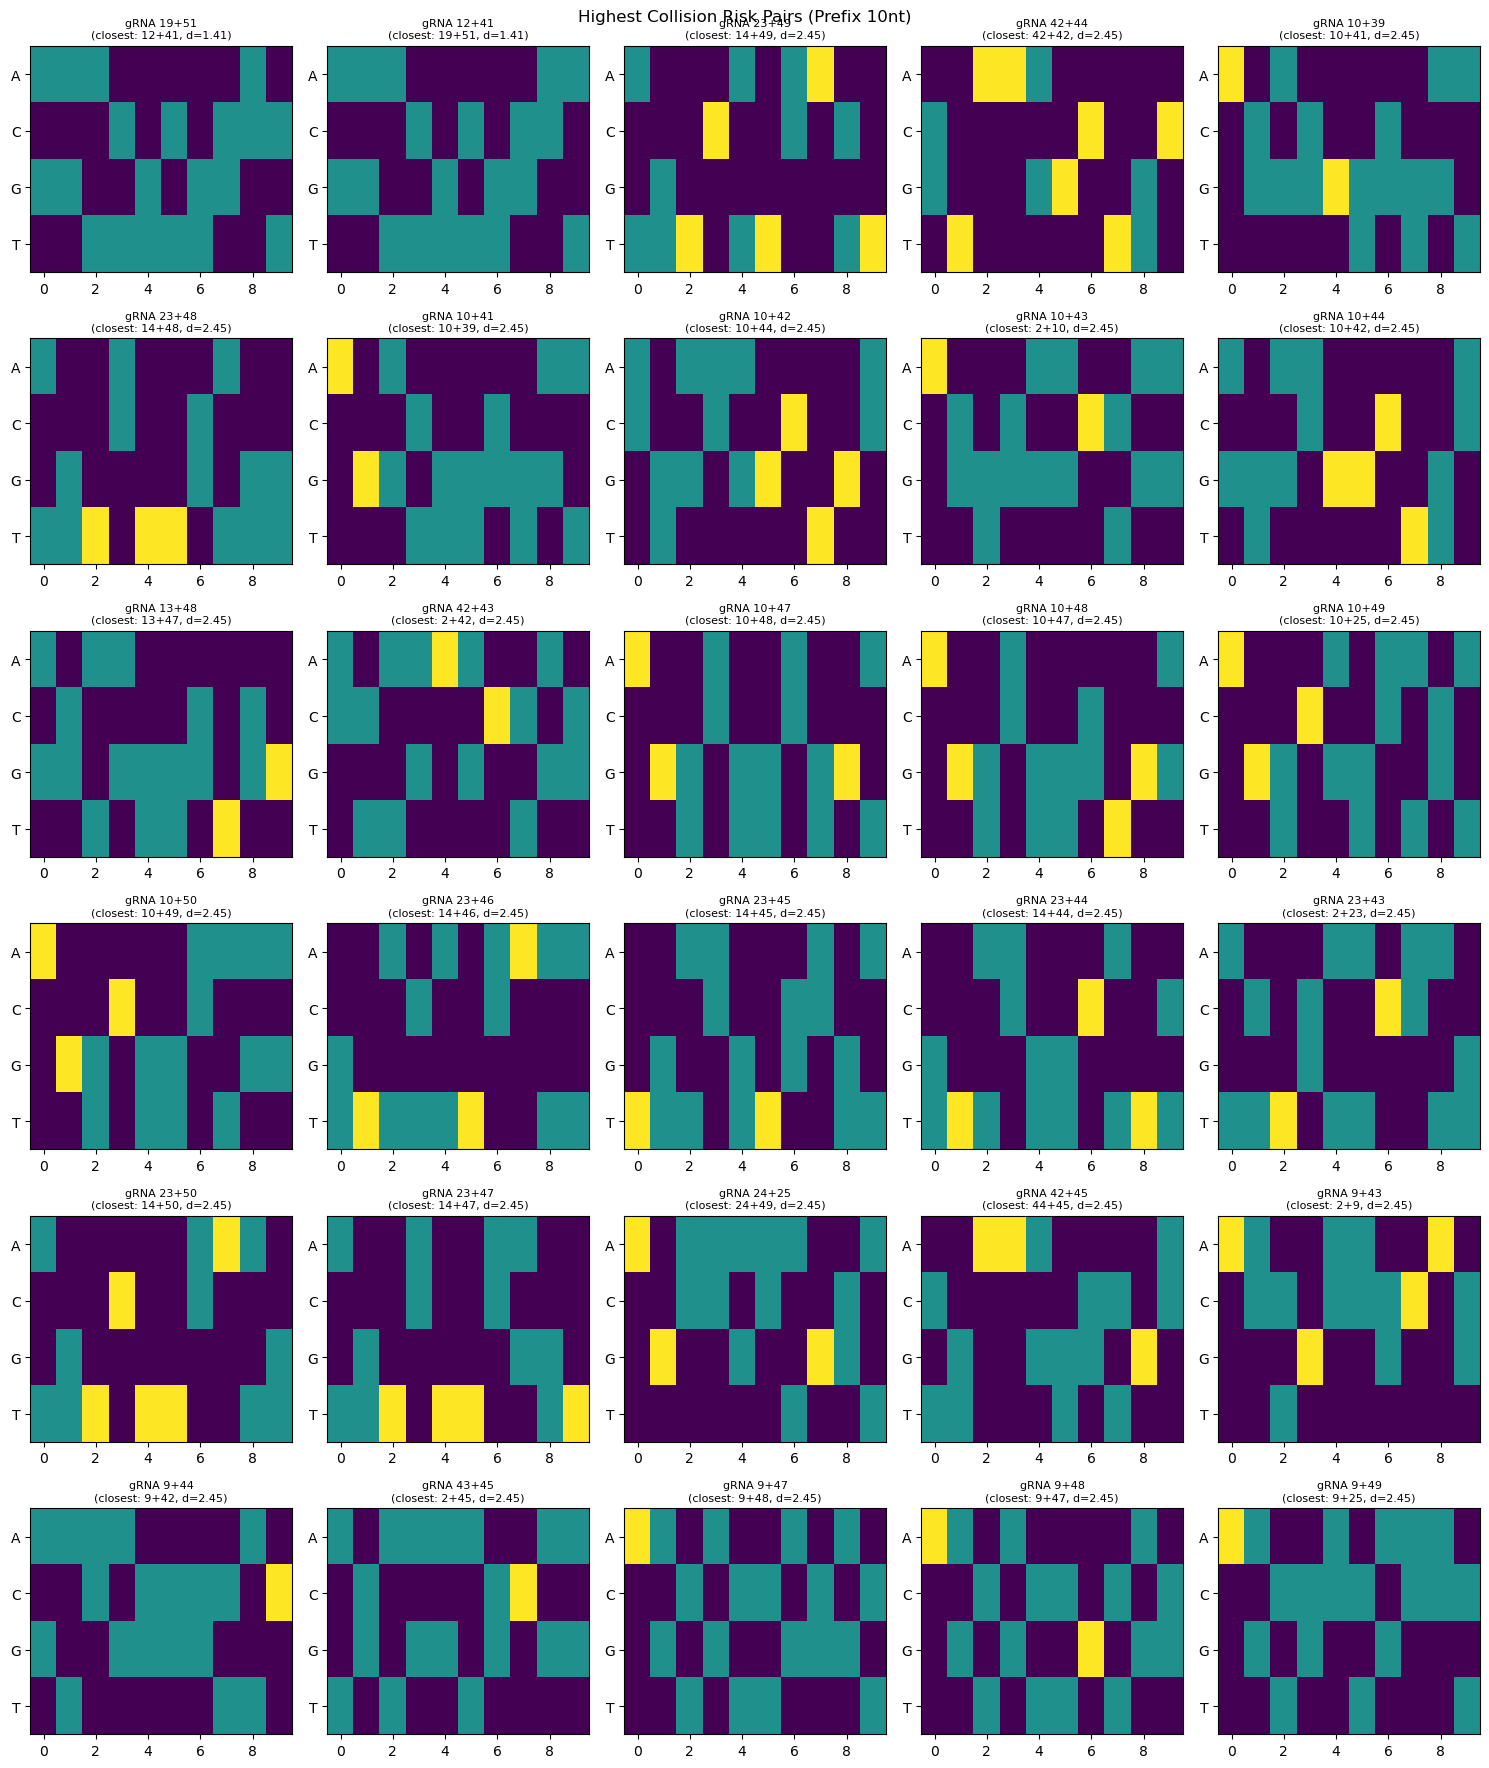

In [32]:
# Uses your notebook’s built-in function (recommended)
visualize_imaging_matrix(
    spacers,
    prefix_len=10,        # try 10 and 20 separately
    n_show=30,            # number of examples to show
    output_path=None      # or "fig2_near_collisions_L10.png"
)

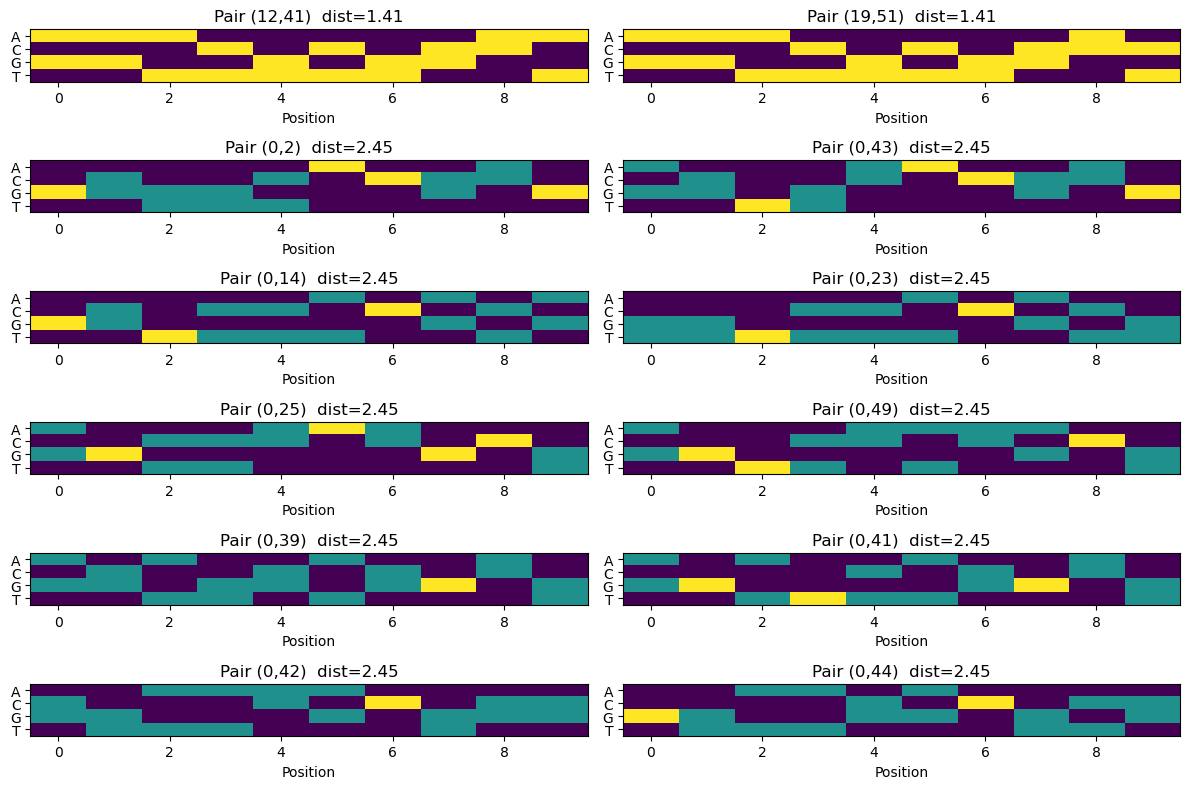

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

def flatten_signal(sig):
    # sig shape (L,4) -> vector
    return sig.reshape(-1).astype(float)

def pair_signal(spacers, i, j, L):
    return compute_pair_sum(spacers[i], spacers[j], prefix_len=L)

def plot_signal_heatmap(sig, title):
    plt.imshow(sig.T, aspect="auto")  # channels x position
    plt.yticks([0,1,2,3], ["A","C","G","T"])
    plt.xlabel("Position")
    plt.title(title)

# --- Parameters ---
L = 10
pairs = list(combinations_with_replacement(range(len(spacers)), 2))

# Build all signals
signals = [pair_signal(spacers, i, j, L) for (i, j) in pairs]
X = np.stack([flatten_signal(s) for s in signals], axis=0)

# Find most similar *distinct* pair-sums (excluding identical index)
# We do a cheap O(N^2) since N ~ 465 for 30 gRNAs.
best = []  # list of (dist, idx_a, idx_b)
for a in range(len(pairs)):
    for b in range(a+1, len(pairs)):
        d = np.linalg.norm(X[a] - X[b])
        best.append((d, a, b))

best.sort(key=lambda t: t[0])
top = best[:6]  # show 6 closest pair-sum pairs

# Plot
plt.figure(figsize=(12, 8))
for k, (d, a, b) in enumerate(top, start=1):
    i1, j1 = pairs[a]
    i2, j2 = pairs[b]
    sig1 = signals[a]
    sig2 = signals[b]

    plt.subplot(len(top), 2, 2*k-1)
    plot_signal_heatmap(sig1, f"Pair ({i1},{j1})  dist={d:.2f}")
    plt.subplot(len(top), 2, 2*k)
    plot_signal_heatmap(sig2, f"Pair ({i2},{j2})  dist={d:.2f}")

plt.tight_layout()
plt.show()

In [34]:
imaging_matrix, pairs = generate_imaging_matrix(spacers, prefix_len=10)
idx = pairs.index((0,25))
sig_from_matrix = imaging_matrix[idx]
sig_direct = compute_pair_sum(spacers[0], spacers[25], prefix_len=10)
print("Matrix vs direct equal?", np.array_equal(sig_from_matrix, sig_direct))
print("matrix unique:", np.unique(sig_from_matrix), "direct unique:", np.unique(sig_direct))


Matrix vs direct equal? True
matrix unique: [0. 1. 2.] direct unique: [0 1 2]


In [29]:
print(len("TGGAAAGGACGAAACACCGG"))

20
